In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import backend as K

In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
(x_train,y_train), (x_test,y_test) = mnist.load_data()

x_train [Shape (60000, 28, 28)] sample patch 
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


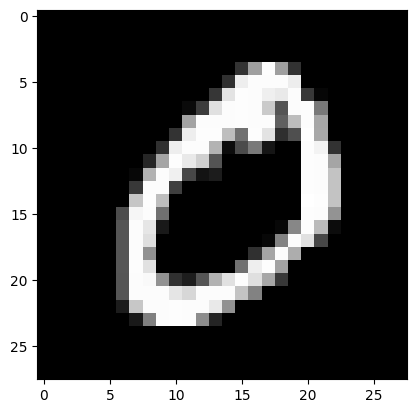

In [4]:
print("x_train [Shape %s] sample patch \n"%(str(x_train.shape)),x_train[1,15:20,5:10])
plt.imshow(x_train[1], cmap='grey')
plt.show()
# print(str(x_train[0]))

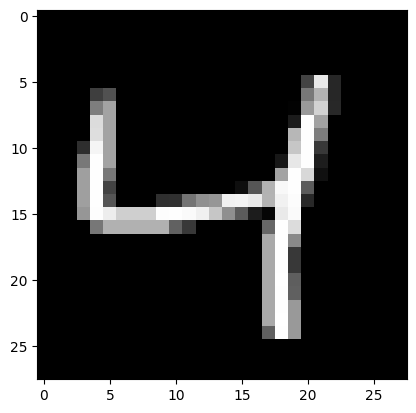

In [5]:
plt.imshow(x_train[2], cmap='grey')
plt.show()

In [6]:
(x_train,y_train), (x_test,y_test) = mnist.load_data()

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(200, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(60, activation='relu'),
        tf.keras.layers.Dense(30, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ]
)
model.summary()

d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [8]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9049 - loss: 0.3119 - val_accuracy: 0.9605 - val_loss: 0.1330
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9653 - loss: 0.1125 - val_accuracy: 0.9604 - val_loss: 0.1388
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9758 - loss: 0.0761 - val_accuracy: 0.9625 - val_loss: 0.1308
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9811 - loss: 0.0574 - val_accuracy: 0.9749 - val_loss: 0.0900
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9852 - loss: 0.0446 - val_accuracy: 0.9680 - val_loss: 0.1118
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9881 - loss: 0.0366 - val_accuracy: 0.9732 - val_loss: 0.1003
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9893 - loss: 0.0322 - val_accuracy: 0.9757 - val_loss: 0.0941
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9916 - loss: 0.0250 - val_accuracy: 0.

In [9]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - accuracy: 0.9770 - loss: 0.1015
test accuracy: 0.9769999980926514


In [10]:
import numpy as np
def get_random_indices(total_images, num_images):
    indices = np.random.choice(total_images, num_images, replace=False)
    return indices


In [11]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1,28,28)
predictions_classes = np.argmax(predictions, axis=1)
true_classes =  np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step


In [12]:
num_images_to_show = 5
random_indices = get_random_indices(len(x_test_images), num_images_to_show)
def plot_images(images, labels, predictions):
    plt.figure(figsize=(10, 9))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(images[i],cmap='gray')
        plt.title(f"Actual: {labels[i]}, \n Predicted: {predictions[i]}")
        plt.show()


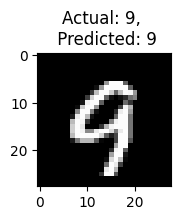

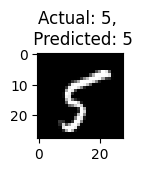

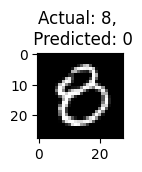

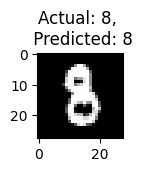

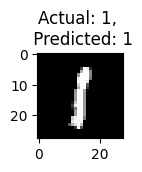

In [13]:
plot_images(x_test_images[random_indices], true_classes[random_indices], predictions_classes[random_indices])

In [14]:
from tensorflow.keras.callbacks import TensorBoard
Name = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir=f'logs/{Name}')

(x_train,y_train), (x_test,y_test) = mnist.load_data()

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(200, activation='relu', input_shape=(784,)),
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(60, activation='relu'),
        tf.keras.layers.Dense(30, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ]
)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"test accuracy: {test_acc}")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9071 - loss: 0.3048 - val_accuracy: 0.9588 - val_loss: 0.1426
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9660 - loss: 0.1146 - val_accuracy: 0.9687 - val_loss: 0.1110
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9752 - loss: 0.0787 - val_accuracy: 0.9716 - val_loss: 0.0975
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9818 - loss: 0.0602 - val_accuracy: 0.9718 - val_loss: 0.0987
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9845 - loss: 0.0471 - val_accuracy: 0.9716 - val_loss: 0.1071
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9878 - loss: 0.0382 - val_accuracy: 0.9712 - val_loss: 0.1082
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0305 - val_accuracy: 0.9722 - val_loss: 0.1019
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9915 - loss: 0.0274 - val_accuracy: 0.

In [20]:
!tensorboard --logdir = logs --port = 6006

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "D:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "D:\Gemy Study\DEPI\Machine learning DEPI round_4\TEC\Amit-1\Amit_env\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'


In [17]:
!pip install pkg_resources

ERROR: Could not find a version that satisfies the requirement pkg_resources (from versions: none)
ERROR: No matching distribution found for pkg_resources


In [18]:
import pkg_resources

ModuleNotFoundError: No module named 'pkg_resources'

In [19]:
!pip install --upgrade setuptools